### Quiz-5
1. 결측치
    * 대여거치대는 대여소번호와 맞는 거치대의 평균값으로 진행 하시오.(소수점수는 버림으로 진행하세요)
    * 반납거치대는 반납대여소번호와 맞는 최빈값으로 진행 하시오
    * 이용 시간과 이용거리는 대여소명과 반납소명과 일치하는 중위수로 진행 하시오.
        - 참고 : df.to_dict('list') DataFrame의 값을 딕셔너리 형태로 바꿔 준다.
2. 문자열(대여소명, 반납대여소명은 수치화 하여 진행하세요)
    * 대여소명은 대여소명_숫자 컬럼에 저장
    * 반납대여소명은 반납대여소명_숫자 컬럼에 저장
    
3. 이상치(나이, 이용시간, 이용거리)
    * 나이는 전체 데이터의 중위수로 치환하세요(iqr * 3)
    * 이용시간과 이용거리는 각 대여소번호와 반납대여소번호와 일치하는 중앙값으로 처리하세요(iqr * 1.5)
4. 중복값
    * 중복 행은 삭제 하세요
5. 시계열
    * 대여 시간대별 자전거 빌리는 양을 구하세요

In [75]:
import pandas as pd
df = pd.read_csv('../../data_set/2.데이터 클린징/bicycle.csv')
df.head()

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이
0,SPB-23220,2019-11-01 8:48,646,장한평역 1번출구 (국민은행앞),3.0,2019-11-01 9:01,3,중랑센터,7.0,12.0,1100.0,50
1,SPB-16216,2019-11-04 8:38,646,장한평역 1번출구 (국민은행앞),2.0,2019-11-04 8:56,3,중랑센터,2.0,7.0,1420.0,31
2,SPB-21097,2019-11-04 8:46,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-04 8:57,3,중랑센터,7.0,10.0,NaN,32
3,SPB-22292,2019-11-05 8:34,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,NaN,10.0,1380.0,21
4,SPB-07935,2019-11-05 12:29,512,뚝섬역 1번 출구 옆,11.0,2019-11-05 12:39,3,중랑센터,7.0,10.0,1650.0,120


In [76]:
df.isnull().sum()

자전거번호       0
대여일시        0
대여소번호       0
대여소명        0
대여거치대      23
반납일시        0
반납대여소번호     0
반납대여소명      0
반납거치대      11
이용시간       11
이용거리       11
나이          0
dtype: int64

In [77]:
df.dtypes

자전거번호          str
대여일시           str
대여소번호        int64
대여소명           str
대여거치대      float64
반납일시           str
반납대여소번호      int64
반납대여소명         str
반납거치대      float64
이용시간       float64
이용거리       float64
나이           int64
dtype: object

## 결측치

### 대여거치대

In [78]:
idx_1 = df[ df['대여거치대'].isnull() ].index

In [79]:
# 대여거치대는 대여소번호와 맞는 거치대의 평균값으로 진행 하시오.(소수점수는 버림으로 진행하세요)
import math

for idx in df[ df['대여거치대'].isnull() ].index :
    df.loc[idx, '대여거치대'] = math.floor(df[ df['대여소번호'] == df.loc[idx, '대여소번호'] ]['대여거치대'].mean())
df.loc[list(idx_1)]

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이
13,SPB-19645,2019-11-14 9:44,646,장한평역 1번출구 (국민은행앞),4.0,2019-11-14 10:01,3,중랑센터,7.0,16.0,1140.0,59
18,SPB-23659,2019-11-21 8:36,646,장한평역 1번출구 (국민은행앞),4.0,2019-11-21 8:44,3,중랑센터,2.0,6.0,1130.0,33
25,SPB-19643,2019-11-06 8:43,419,홈플러스 앞,13.0,2019-11-06 9:26,5,상암센터 정비실,5.0,42.0,450.0,41
29,SPB-21611,2019-11-27 8:34,911,은평평화공원(역촌역4번출구),6.0,2019-11-27 8:55,5,상암센터 정비실,6.0,NaN,5350.0,38
49,SPB-17169,2019-11-01 18:32,148,용강동 주민센터 앞,5.0,2019-11-01 19:05,101,(구)합정동 주민센터,2.0,32.0,5440.0,24
64,SPB-15349,2019-11-02 1:14,104,합정역 1번출구 앞,6.0,2019-11-02 1:20,101,(구)합정동 주민센터,1.0,5.0,1040.0,42
72,SPB-01372,2019-11-02 15:34,104,합정역 1번출구 앞,6.0,2019-11-02 15:43,101,(구)합정동 주민센터,2.0,8.0,1230.0,42
87,SPB-08676,2019-11-02 19:53,101,(구)합정동 주민센터,2.0,2019-11-02 21:13,101,(구)합정동 주민센터,1.0,69.0,2230.0,26
89,SPB-03614,2019-11-02 20:28,419,홈플러스 앞,13.0,2019-11-02 21:15,101,(구)합정동 주민센터,NaN,46.0,5720.0,24
103,SPB-10191,2019-11-03 11:56,105,합정역 5번출구 앞,1.0,2019-11-03 12:35,101,(구)합정동 주민센터,4.0,38.0,1610.0,24


In [80]:
# 반납거치대는 반납대여소번호와 맞는 최빈값으로 진행 하시오
idx_2 = df[ df['반납거치대'].isnull() ].index
idx_2

Index([3, 23, 40, 51, 74, 89, 204, 265, 308, 408, 416], dtype='int64')

In [81]:
for idx in idx_2 :
    df.loc[idx, '반납거치대'] = df[ df['반납대여소번호'] == df.loc[idx, '반납대여소번호'] ]['반납거치대'].mode().loc[0]

df.loc[list(idx_2)]

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이
3,SPB-22292,2019-11-05 8:34,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,2.0,10.0,1380.0,21
23,SPB-19256,2019-11-26 10:20,3,중랑센터,7.0,2019-11-26 10:24,3,중랑센터,2.0,3.0,0.0,29
40,SPB-25272,2019-11-01 8:13,956,응암시장교차로,5.0,2019-11-01 8:42,101,(구)합정동 주민센터,1.0,27.0,6670.0,26
51,SPB-00122,2019-11-01 18:55,113,홍대입구역 2번출구 앞,25.0,2019-11-01 19:14,101,(구)합정동 주민센터,1.0,19.0,2790.0,26
74,SPB-21518,2019-11-02 16:00,116,일진아이윌아파트 옆,3.0,2019-11-02 16:49,101,(구)합정동 주민센터,1.0,46.0,3980.0,22
89,SPB-03614,2019-11-02 20:28,419,홈플러스 앞,13.0,2019-11-02 21:15,101,(구)합정동 주민센터,1.0,46.0,5720.0,24
204,SPB-23327,2019-11-05 22:14,391,정동길입구,2.0,2019-11-05 22:54,101,(구)합정동 주민센터,1.0,37.0,7210.0,55
265,SPB-08123,2019-11-08 11:42,113,홍대입구역 2번출구 앞,19.0,2019-11-08 11:54,101,(구)합정동 주민센터,1.0,11.0,2150.0,43
308,SPB-10067,2019-11-09 21:37,108,서교동 사거리,1.0,2019-11-09 21:58,101,(구)합정동 주민센터,1.0,20.0,1270.0,25
408,SPB-07283,2019-11-14 22:15,152,마포구민체육센터 앞,17.0,2019-11-14 22:26,101,(구)합정동 주민센터,1.0,11.0,0.0,39


In [82]:
# 이용 시간과 이용거리는 대여소명과 반납소명과 일치하는 중위수로 진행 하시오.
# 참고 : df.to_dict('list') DataFrame의 값을 딕셔너리 형태로 바꿔 준다.
df[ df['이용시간'].isnull() ]

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이
11,SPB-20145,2019-11-13 8:30,646,장한평역 1번출구 (국민은행앞),9.0,2019-11-13 8:38,3,중랑센터,2.0,NaN,1060.0,34
16,SPB-22311,2019-11-18 8:32,646,장한평역 1번출구 (국민은행앞),6.0,2019-11-18 8:39,3,중랑센터,2.0,NaN,1350.0,31
22,SPB-05857,2019-11-26 8:40,646,장한평역 1번출구 (국민은행앞),6.0,2019-11-26 8:48,3,중랑센터,2.0,NaN,1380.0,41
29,SPB-21611,2019-11-27 8:34,911,은평평화공원(역촌역4번출구),6.0,2019-11-27 8:55,5,상암센터 정비실,6.0,NaN,5350.0,38
57,SPB-07887,2019-11-01 20:22,104,합정역 1번출구 앞,6.0,2019-11-01 20:30,101,(구)합정동 주민센터,3.0,NaN,770.0,31
86,SPB-04854,2019-11-02 19:52,101,(구)합정동 주민센터,5.0,2019-11-02 21:01,101,(구)합정동 주민센터,2.0,NaN,2300.0,220
161,SPB-04641,2019-11-04 21:33,101,(구)합정동 주민센터,3.0,2019-11-04 21:42,101,(구)합정동 주민센터,1.0,NaN,0.0,45
228,SPB-17074,2019-11-06 18:33,267,삼성화재 사옥 옆,2.0,2019-11-06 18:49,101,(구)합정동 주민센터,2.0,NaN,2390.0,31
311,SPB-18301,2019-11-09 23:40,103,망원역 2번출구 앞,9.0,2019-11-10 0:21,101,(구)합정동 주민센터,4.0,NaN,6510.0,22
332,SPB-06200,2019-11-11 14:26,115,사루비아 빌딩 앞,1.0,2019-11-11 14:44,101,(구)합정동 주민센터,4.0,NaN,0.0,41


In [83]:
# df.loc[idx, '반납거치대'] = df[ df['반납대여소번호'] == df.loc[idx, '반납대여소번호'] ]['반납거치대'].mode().loc[0]
for col in ['이용시간', '이용거리'] :
    idx_temp = df[ df[col].isnull() ].index
    for idx in idx_temp :
        df.loc[idx, col] = df[ (df['대여소명'] == df.loc[idx, '대여소명']) & (df['반납대여소명'] == df.loc[idx, '반납대여소명']) ][col].median()
    print(df.loc[list(idx_temp)])
    print("=" * 40)

         자전거번호              대여일시  대여소번호               대여소명  대여거치대  \
11   SPB-20145   2019-11-13 8:30    646  장한평역 1번출구 (국민은행앞)    9.0   
16   SPB-22311   2019-11-18 8:32    646  장한평역 1번출구 (국민은행앞)    6.0   
22   SPB-05857   2019-11-26 8:40    646  장한평역 1번출구 (국민은행앞)    6.0   
29   SPB-21611   2019-11-27 8:34    911    은평평화공원(역촌역4번출구)    6.0   
57   SPB-07887  2019-11-01 20:22    104         합정역 1번출구 앞    6.0   
86   SPB-04854  2019-11-02 19:52    101        (구)합정동 주민센터    5.0   
161  SPB-04641  2019-11-04 21:33    101        (구)합정동 주민센터    3.0   
228  SPB-17074  2019-11-06 18:33    267          삼성화재 사옥 옆    2.0   
311  SPB-18301  2019-11-09 23:40    103         망원역 2번출구 앞    9.0   
332  SPB-06200  2019-11-11 14:26    115          사루비아 빌딩 앞    1.0   
400  SPB-15391  2019-11-14 17:14    113       홍대입구역 2번출구 앞   22.0   

                 반납일시  반납대여소번호       반납대여소명  반납거치대  이용시간    이용거리   나이  
11    2019-11-13 8:38        3         중랑센터    2.0  10.0  1060.0   34  
16    2019-11-18 8:39      

In [84]:
df.isnull().sum()

자전거번호      0
대여일시       0
대여소번호      0
대여소명       0
대여거치대      0
반납일시       0
반납대여소번호    0
반납대여소명     0
반납거치대      0
이용시간       0
이용거리       0
나이         0
dtype: int64

## 문자열

In [85]:
# 문자열(대여소명, 반납대여소명은 수치화 하여 진행하세요)

# 대여소명은 대여소명_숫자 컬럼에 저장
# 반납대여소명은 반납대여소명_숫자 컬럼에 저장

In [86]:
df['대여소명']

0      장한평역 1번출구 (국민은행앞)
1      장한평역 1번출구 (국민은행앞)
2      장한평역 1번출구 (국민은행앞)
3      장한평역 1번출구 (국민은행앞)
4            뚝섬역 1번 출구 옆
             ...        
418           마포구민체육센터 앞
419                정동길입구
420            삼성화재 사옥 옆
421           합정역 7번출구 앞
422      은평평화공원(역촌역4번출구)
Name: 대여소명, Length: 423, dtype: str

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit( df['대여소명'])
df['대여소명_숫자'] = le.transform(df['대여소명'])
df

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이,대여소명_숫자
0,SPB-23220,2019-11-01 8:48,646,장한평역 1번출구 (국민은행앞),3.0,2019-11-01 9:01,3,중랑센터,7.0,12.0,1100.0,50,62
1,SPB-16216,2019-11-04 8:38,646,장한평역 1번출구 (국민은행앞),2.0,2019-11-04 8:56,3,중랑센터,2.0,7.0,1420.0,31,62
2,SPB-21097,2019-11-04 8:46,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-04 8:57,3,중랑센터,7.0,10.0,1310.0,32,62
3,SPB-22292,2019-11-05 8:34,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,2.0,10.0,1380.0,21,62
4,SPB-07935,2019-11-05 12:29,512,뚝섬역 1번 출구 옆,11.0,2019-11-05 12:39,3,중랑센터,7.0,10.0,1650.0,120,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,SPB-24467,2019-11-15 21:55,152,마포구민체육센터 앞,18.0,2019-11-15 22:05,101,(구)합정동 주민센터,1.0,10.0,1180.0,27,15
419,SPB-17570,2019-11-15 22:16,391,정동길입구,7.0,2019-11-15 23:04,101,(구)합정동 주민센터,5.0,48.0,8100.0,28,64
420,SPB-23012,2019-11-14 19:53,267,삼성화재 사옥 옆,2.0,2019-11-14 20:05,101,(구)합정동 주민센터,2.0,12.0,2350.0,41,30
421,SPB-13934,2019-11-13 18:00,106,합정역 7번출구 앞,4.0,2019-11-13 18:06,101,(구)합정동 주민센터,2.0,5.0,860.0,58,71


In [88]:
df['대여소명_숫자'].unique()

array([62, 13, 66, 63, 72, 59, 38, 39, 22,  0, 47, 71, 16, 60, 69, 23, 15,
       36, 73, 57, 34, 48, 30, 27, 41, 64, 70,  2, 17,  9, 61, 20, 11, 75,
       21, 56,  8, 49, 42, 53, 46, 68, 74, 67,  3, 55, 37, 35,  6, 43,  7,
       19, 18, 65,  5, 31, 24, 44, 10, 14, 33, 32, 12, 52, 28,  1, 50, 58,
       45, 54,  4, 26, 25, 29, 40, 51])

In [89]:
le.fit( df['반납대여소명'])
df['반납대여소명_숫자'] = le.transform(df['반납대여소명'])
df

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이,대여소명_숫자,반납대여소명_숫자
0,SPB-23220,2019-11-01 8:48,646,장한평역 1번출구 (국민은행앞),3.0,2019-11-01 9:01,3,중랑센터,7.0,12.0,1100.0,50,62,2
1,SPB-16216,2019-11-04 8:38,646,장한평역 1번출구 (국민은행앞),2.0,2019-11-04 8:56,3,중랑센터,2.0,7.0,1420.0,31,62,2
2,SPB-21097,2019-11-04 8:46,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-04 8:57,3,중랑센터,7.0,10.0,1310.0,32,62,2
3,SPB-22292,2019-11-05 8:34,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,2.0,10.0,1380.0,21,62,2
4,SPB-07935,2019-11-05 12:29,512,뚝섬역 1번 출구 옆,11.0,2019-11-05 12:39,3,중랑센터,7.0,10.0,1650.0,120,13,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,SPB-24467,2019-11-15 21:55,152,마포구민체육센터 앞,18.0,2019-11-15 22:05,101,(구)합정동 주민센터,1.0,10.0,1180.0,27,15,0
419,SPB-17570,2019-11-15 22:16,391,정동길입구,7.0,2019-11-15 23:04,101,(구)합정동 주민센터,5.0,48.0,8100.0,28,64,0
420,SPB-23012,2019-11-14 19:53,267,삼성화재 사옥 옆,2.0,2019-11-14 20:05,101,(구)합정동 주민센터,2.0,12.0,2350.0,41,30,0
421,SPB-13934,2019-11-13 18:00,106,합정역 7번출구 앞,4.0,2019-11-13 18:06,101,(구)합정동 주민센터,2.0,5.0,860.0,58,71,0


In [90]:
df['반납대여소명_숫자'].unique()

array([2, 1, 0])

## 이상치

In [91]:
# 이상치(나이, 이용시간, 이용거리)

# 나이는 전체 데이터의 중위수로 치환하세요(iqr * 3)
# 이용시간과 이용거리는 각 대여소번호와 반납대여소번호와 일치하는 중앙값으로 처리하세요(iqr * 1.5)

### 나이
- 나이는 전체 데이터의 중위수로 치환하세요(iqr * 3)

In [92]:
df.describe()

,대여소번호,대여거치대,반납대여소번호,반납거치대,이용시간,이용거리,나이,대여소명_숫자,반납대여소명_숫자
count,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000
mean,244.565012,7.546099,93.165485,2.791962,20.988180,2655.200946,35.562648,38.997636,0.139480
std,301.904633,6.197930,26.532660,1.688891,19.934902,2983.309935,31.747004,25.325137,0.488665
min,3.000000,1.000000,3.000000,1.000000,2.000000,0.000000,21.000000,0.000000,0.000000
25%,104.000000,3.000000,101.000000,1.000000,7.000000,1070.000000,24.000000,20.000000,0.000000
50%,119.000000,6.000000,101.000000,2.000000,13.000000,1630.000000,29.000000,36.000000,0.000000
75%,228.000000,10.000000,101.000000,4.000000,27.000000,3765.000000,40.500000,65.000000,0.000000
max,3102.000000,30.000000,101.000000,7.000000,122.000000,42070.000000,533.000000,75.000000,2.000000


In [93]:
q1 = df.describe().loc["25%", '나이']
q3 = df.describe().loc["75%", '나이']
print(q1, q3)

iqr = q3 - q1
print(iqr)

lowerfence = q1 - iqr * 3 # 최저 이상치
upperfence = q3 + iqr * 3# 최대 이상치
lowerfence, upperfence

24.0 40.5
16.5


(np.float64(-25.5), np.float64(90.0))

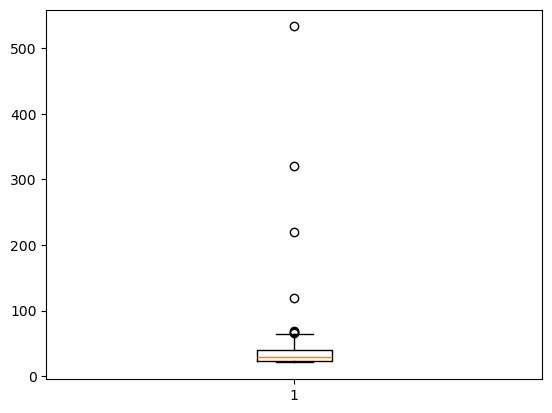

In [94]:
import matplotlib.pyplot as plt

plt.boxplot(df['나이'])
plt.show()

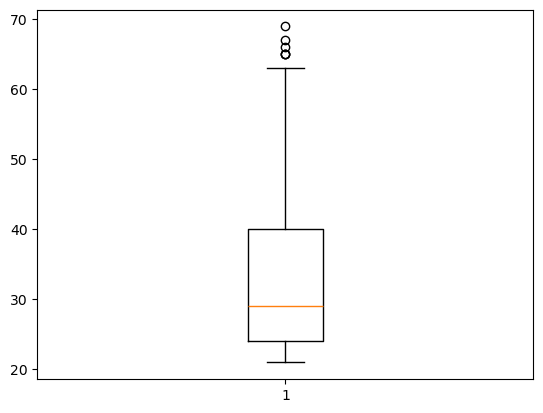

In [95]:
mask = (df['나이'] < lowerfence) | (df['나이'] > upperfence)

df.loc[mask, '나이'] = int(df['나이'].median())

plt.boxplot(df['나이'])
plt.show()

### 이용시간 & 이용거리
- 이용시간과 이용거리는 각 대여소번호와 반납대여소번호와 일치하는 중앙값으로 처리하세요(iqr * 1.5)

#### 이용시간

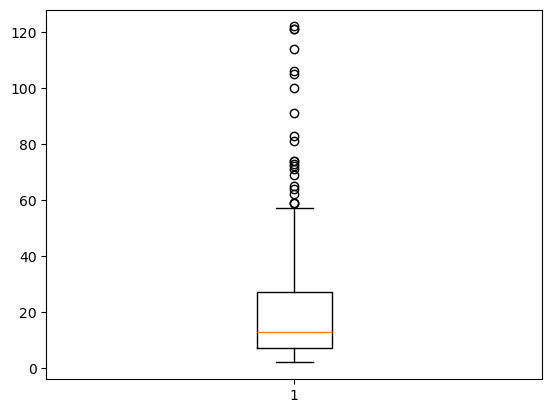

In [96]:
plt.boxplot(df['이용시간'])
plt.show()

In [97]:
def get_fence(col) :
    q1 = df.describe().loc["25%", col]
    q3 = df.describe().loc["75%", col]

    iqr = q3 - q1
    lowerfence = q1 - iqr * 1.5# 최저 이상치
    upperfence = q3 + iqr * 1.5# 최대 이상치
    
    return lowerfence, upperfence

In [98]:
time_lfence, time_ufence = get_fence('이용시간')

In [99]:
time_idx = df[ (df['이용시간'] < time_lfence) | (df['이용시간'] > time_ufence) ].index

In [100]:
for idx in time_idx :
    df.loc[idx, '이용시간'] = df[ (df['대여소명'] == df.loc[idx, '대여소명']) & (df['반납대여소명'] == df.loc[idx, '반납대여소명']) ]['이용시간'].median()

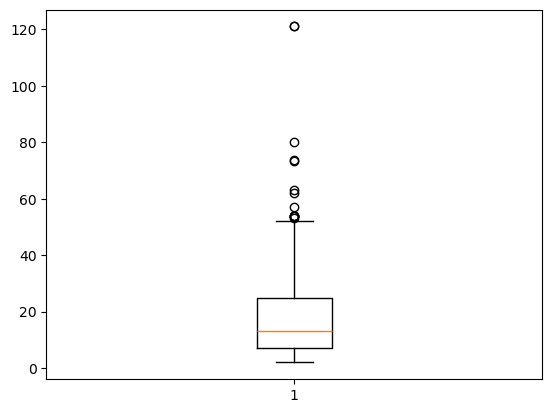

In [101]:
plt.boxplot(df['이용시간'])
plt.show()

#### 이용거리

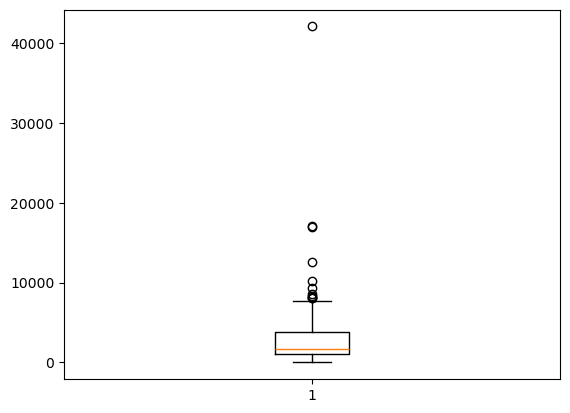

In [102]:
plt.boxplot(df['이용거리'])
plt.show()

In [103]:
dist_lfence, dist_ufence = get_fence('이용거리')
dist_idx = df[ (df['이용거리'] < dist_lfence) | (df['이용거리'] > dist_ufence) ].index

for idx in time_idx :
    df.loc[idx, '이용거리'] = df[ (df['대여소명'] == df.loc[idx, '대여소명']) & (df['반납대여소명'] == df.loc[idx, '반납대여소명']) ]['이용거리'].median()

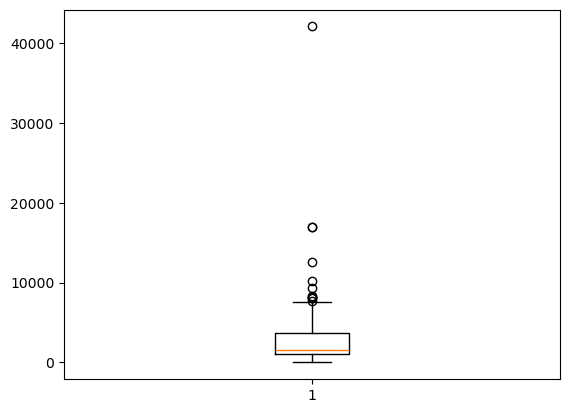

In [105]:
plt.boxplot(df['이용거리'])
plt.show()

## 중복값

- 중복 행은 삭제 하세요

In [107]:
df.shape

(423, 14)

In [109]:
df.drop_duplicates(inplace=True)

In [110]:
df.shape

(420, 14)

## 시계열

- 대여 시간대별 자전거 빌리는 양을 구하세요

In [111]:
df.head()

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이,대여소명_숫자,반납대여소명_숫자
0,SPB-23220,2019-11-01 8:48,646,장한평역 1번출구 (국민은행앞),3.0,2019-11-01 9:01,3,중랑센터,7.0,12.0,1100.0,50,62,2
1,SPB-16216,2019-11-04 8:38,646,장한평역 1번출구 (국민은행앞),2.0,2019-11-04 8:56,3,중랑센터,2.0,7.0,1420.0,31,62,2
2,SPB-21097,2019-11-04 8:46,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-04 8:57,3,중랑센터,7.0,10.0,1310.0,32,62,2
3,SPB-22292,2019-11-05 8:34,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,2.0,10.0,1380.0,21,62,2
4,SPB-07935,2019-11-05 12:29,512,뚝섬역 1번 출구 옆,11.0,2019-11-05 12:39,3,중랑센터,7.0,10.0,1650.0,29,13,2


In [112]:
df.dtypes

자전거번호            str
대여일시             str
대여소번호          int64
대여소명             str
대여거치대        float64
반납일시             str
반납대여소번호        int64
반납대여소명           str
반납거치대        float64
이용시간         float64
이용거리         float64
나이             int64
대여소명_숫자        int64
반납대여소명_숫자      int64
dtype: object

In [113]:
df['대여일시'] = pd.to_datetime(df['대여일시'])

In [114]:
df.dtypes

자전거번호                   str
대여일시         datetime64[us]
대여소번호                 int64
대여소명                    str
대여거치대               float64
반납일시                    str
반납대여소번호               int64
반납대여소명                  str
반납거치대               float64
이용시간                float64
이용거리                float64
나이                    int64
대여소명_숫자               int64
반납대여소명_숫자             int64
dtype: object

In [122]:
df['대여일시'][0].strftime('%Y-%m-%d %H')

'2019-11-01 08'

In [123]:
df['시간'] = df['대여일시'].apply( lambda x : x.strftime('%Y-%m-%d %H'))
df['시간']

0      2019-11-01 08
1      2019-11-04 08
2      2019-11-04 08
3      2019-11-05 08
4      2019-11-05 12
           ...      
415    2019-11-15 04
416    2019-11-15 09
417    2019-11-15 20
418    2019-11-15 21
419    2019-11-15 22
Name: 시간, Length: 420, dtype: str

In [124]:
df

,자전거번호,대여일시,대여소번호,대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리,나이,대여소명_숫자,반납대여소명_숫자,시간
0,SPB-23220,2019-11-01 08:48:00,646,장한평역 1번출구 (국민은행앞),3.0,2019-11-01 9:01,3,중랑센터,7.0,12.0,1100.0,50,62,2,2019-11-01 08
1,SPB-16216,2019-11-04 08:38:00,646,장한평역 1번출구 (국민은행앞),2.0,2019-11-04 8:56,3,중랑센터,2.0,7.0,1420.0,31,62,2,2019-11-04 08
2,SPB-21097,2019-11-04 08:46:00,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-04 8:57,3,중랑센터,7.0,10.0,1310.0,32,62,2,2019-11-04 08
3,SPB-22292,2019-11-05 08:34:00,646,장한평역 1번출구 (국민은행앞),1.0,2019-11-05 8:45,3,중랑센터,2.0,10.0,1380.0,21,62,2,2019-11-05 08
4,SPB-07935,2019-11-05 12:29:00,512,뚝섬역 1번 출구 옆,11.0,2019-11-05 12:39,3,중랑센터,7.0,10.0,1650.0,29,13,2,2019-11-05 12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,SPB-12116,2019-11-15 04:22:00,112,극동방송국 앞,5.0,2019-11-15 4:33,101,(구)합정동 주민센터,1.0,11.0,2200.0,22,8,0,2019-11-15 04
416,SPB-17768,2019-11-15 09:31:00,103,망원역 2번출구 앞,14.0,2019-11-15 9:37,101,(구)합정동 주민센터,1.0,5.0,765.0,22,23,0,2019-11-15 09
417,SPB-18841,2019-11-15 20:40:00,113,홍대입구역 2번출구 앞,24.0,2019-11-15 20:53,101,(구)합정동 주민센터,1.0,12.0,2280.0,37,73,0,2019-11-15 20
418,SPB-24467,2019-11-15 21:55:00,152,마포구민체육센터 앞,18.0,2019-11-15 22:05,101,(구)합정동 주민센터,1.0,10.0,1180.0,27,15,0,2019-11-15 21


In [128]:
df['시간'].value_counts().sort_index()

시간
2019-11-01 00    1
2019-11-01 01    1
2019-11-01 02    3
2019-11-01 03    1
2019-11-01 06    1
                ..
2019-11-26 08    2
2019-11-26 10    1
2019-11-27 08    1
2019-11-28 08    3
2019-11-29 08    1
Name: count, Length: 210, dtype: int64